# 📈 Stock Analysis with yfinance & matplotlib

**Session 4 — Software Engineering & ML, Frankfurt UAS**

This notebook shows how everything from today's lecture comes together
in a real mini-project: downloading stock data and visualizing it.

**What you'll learn:**
- How to install & use a third-party library (`yfinance`)
- How to work with real stock data as a pandas DataFrame
- How to plot prices and indicators with `matplotlib`
- How notebooks let you explore data step by step

**Requirements:**
```
pip install yfinance matplotlib pandas
```
(Inside your activated venv!)

## 1. Setup & Imports

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Make plots appear inline in the notebook
%matplotlib inline

# Nicer plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

## 2. Download Stock Data

`yf.download()` fetches historical price data from Yahoo Finance.
No API key needed — it just works.

In [ ]:
# Download 1 year of Apple data
ticker = "AAPL"
df = yf.download(ticker, period="1y")

# What does the data look like?
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-04-25,208.371811,208.839773,205.305175,205.474435,38222300
2025-04-28,209.228119,210.582218,206.559756,209.088727,38743100
2025-04-29,210.293457,211.318986,207.465770,207.784388,36827600
2025-04-30,211.577850,212.653165,205.773148,208.391740,52286500
2025-05-01,212.394302,213.628912,207.993470,208.172696,57365700
2025-05-02,204.458893,206.091775,201.282733,205.195672,101010600
2025-05-05,198.026917,203.214314,197.349875,202.218654,69018500
2025-05-06,197.648575,199.779288,196.165050,197.349889,51216500


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-04-28,209.228104,210.582203,206.559741,209.088712,38743100
2025-04-29,210.293457,211.318986,207.465770,207.784388,36827600
2025-04-30,211.577850,212.653165,205.773148,208.391740,52286500
2025-05-01,212.394302,213.628912,207.993470,208.172696,57365700
2025-05-02,204.458893,206.091775,201.282733,205.195672,101010600
2025-05-05,198.026901,203.214299,197.349859,202.218638,69018500
2025-05-06,197.648560,199.779272,196.165035,197.349874,51216500
2025-05-07,195.398361,198.574520,192.411380,198.305688,68536700


In [3]:
# Basic info
print(f"Ticker:      {ticker}")
print(f"Date range:  {df.index[0].date()} to {df.index[-1].date()}")
print(f"Trading days: {len(df)}")
print(f"Columns:     {list(df.columns)}")

Ticker:      AAPL
Date range:  2025-04-25 to 2026-04-24
Trading days: 251
Columns:     [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


## 3. Your First Plot — Closing Prices

`df["Close"].plot()` is all you need. Matplotlib does the rest.

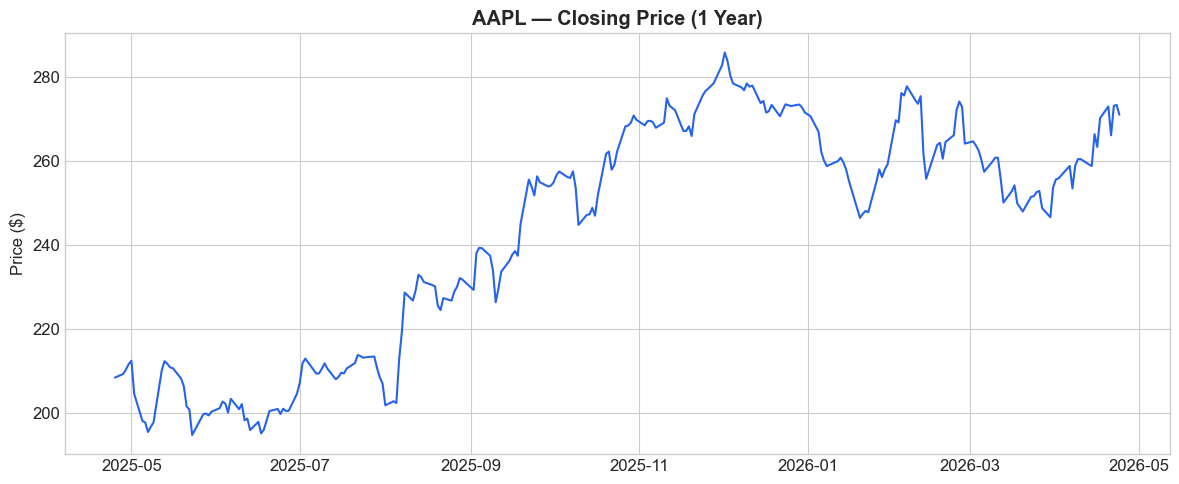

In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="#2563EB", linewidth=1.5)
ax.set_title(f"{ticker} — Closing Price (1 Year)", fontweight="bold")
ax.set_ylabel("Price ($)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 4. Volume — How Much Was Traded?

Volume bars tell you how active the market was on each day.
High volume on a price move = strong conviction.

TypeError: only 0-dimensional arrays can be converted to Python scalars

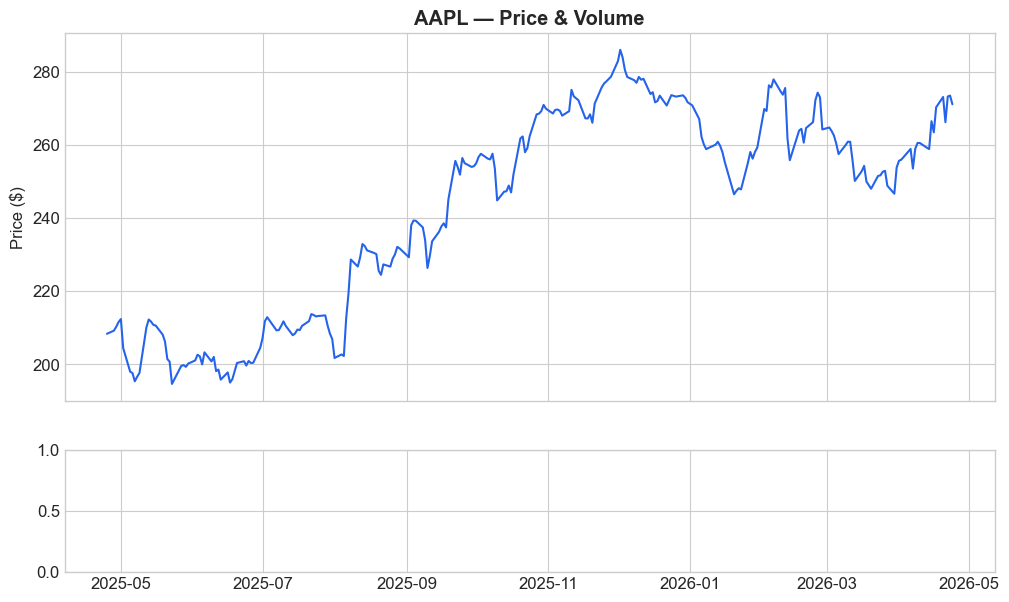

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1], sharex=True)

# Price on top
ax1.plot(df.index, df["Close"], color="#2563EB", linewidth=1.5)
ax1.set_title(f"{ticker} — Price & Volume", fontweight="bold")
ax1.set_ylabel("Price ($)")

# Volume on bottom
ax2.bar(df.index, df["Volume"], color="#F59E0B", alpha=0.7, width=1)
ax2.set_ylabel("Volume")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.show()

## 5. Moving Average — Smoothing the Noise

A moving average (MA) smooths out daily fluctuations.
- **Short MA (20 days):** reacts fast, close to the price
- **Long MA (50 days):** reacts slowly, shows the trend

When the short MA crosses above the long MA → bullish signal ("golden cross").
When it crosses below → bearish signal ("death cross").

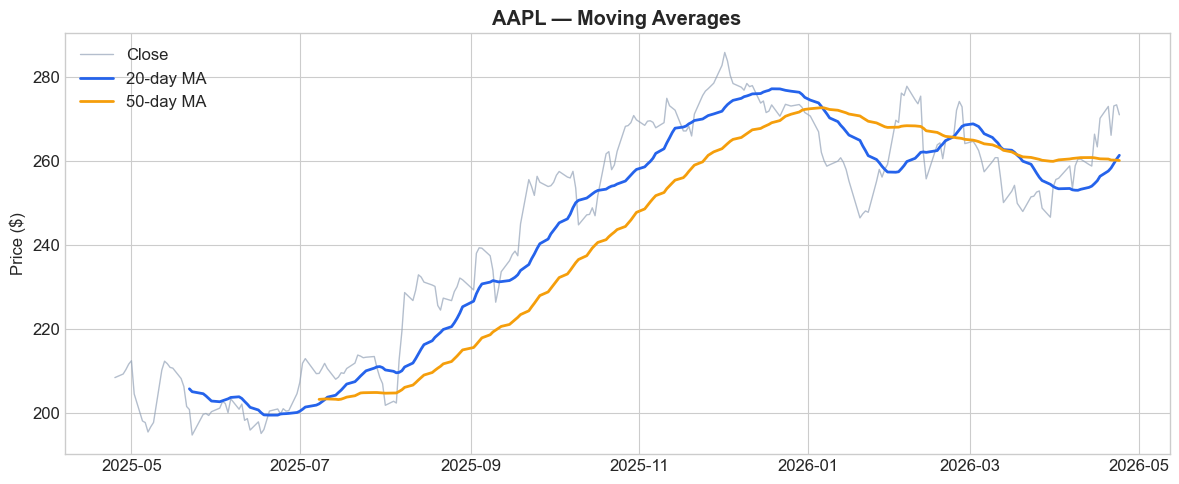

In [ ]:
# Calculate moving averages
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="#94A3B8", linewidth=1, label="Close", alpha=0.7)
ax.plot(df.index, df["MA20"], color="#2563EB", linewidth=2, label="20-day MA")
ax.plot(df.index, df["MA50"], color="#F59E0B", linewidth=2, label="50-day MA")
ax.set_title(f"{ticker} — Moving Averages", fontweight="bold")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. RSI — Is the Stock Overbought or Oversold?

The Relative Strength Index (RSI) measures momentum on a scale of 0–100.
- **RSI > 70** → overbought (price might drop)
- **RSI < 30** → oversold (price might bounce)

This is the indicator from our stock app!

In [ ]:
def calculate_rsi(prices, window=14):
    """Calculate RSI from a Series of closing prices."""
    delta = prices.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["RSI"] = calculate_rsi(df["Close"])

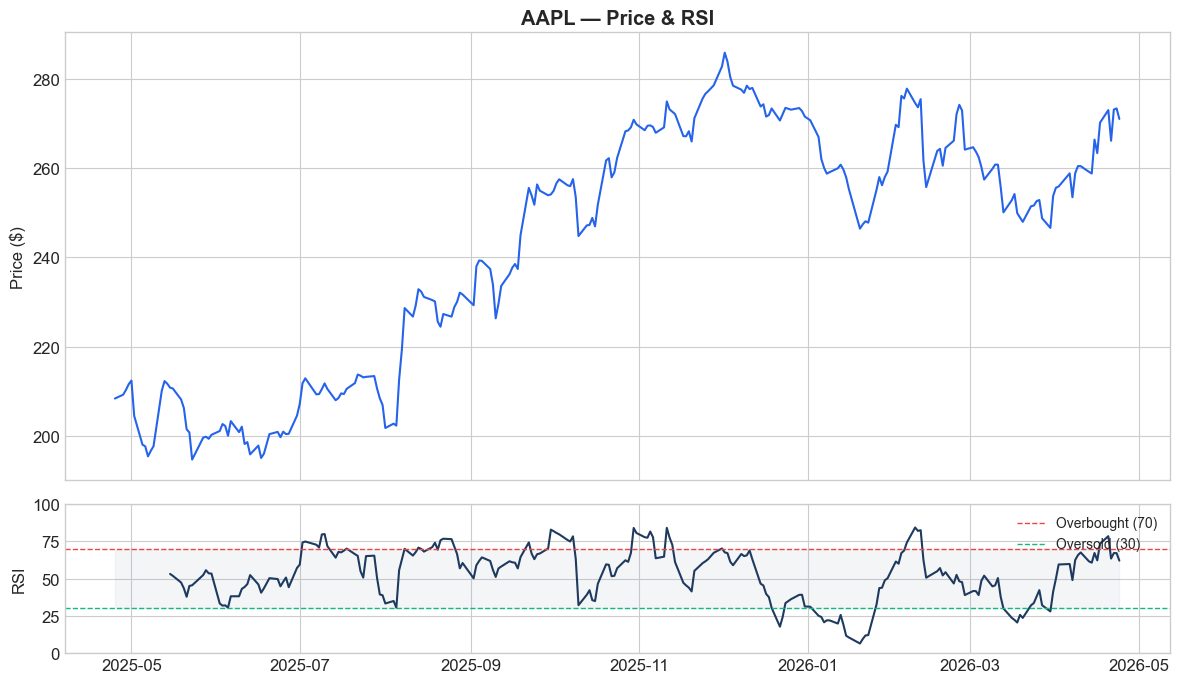

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1], sharex=True)

# Price on top
ax1.plot(df.index, df["Close"], color="#2563EB", linewidth=1.5)
ax1.set_title(f"{ticker} — Price & RSI", fontweight="bold")
ax1.set_ylabel("Price ($)")

# RSI on bottom
ax2.plot(df.index, df["RSI"], color="#1E3A5F", linewidth=1.5)
ax2.axhline(70, color="#EF4444", linewidth=1, linestyle="--", label="Overbought (70)")
ax2.axhline(30, color="#10B981", linewidth=1, linestyle="--", label="Oversold (30)")
ax2.fill_between(df.index, 30, 70, alpha=0.1, color="#94A3B8")
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Compare Multiple Stocks

Download several tickers at once and plot them together.
We normalize prices to start at 100 so they're on the same scale.

[*********************100%***********************]  4 of 4 completed


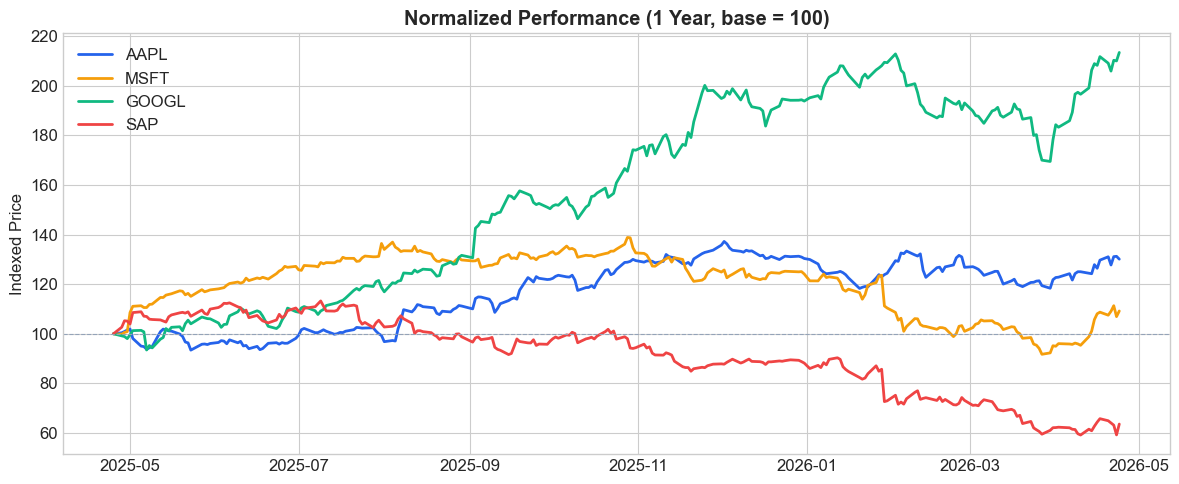

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL", "SAP"]
data = yf.download(tickers, period="1y")

# Normalize: each stock starts at 100
normalized = data["Close"] / data["Close"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2563EB", "#F59E0B", "#10B981", "#EF4444"]

for ticker, color in zip(tickers, colors):
    ax.plot(normalized.index, normalized[ticker], label=ticker,
            linewidth=2, color=color)

ax.axhline(100, color="#94A3B8", linewidth=0.8, linestyle="--")
ax.set_title("Normalized Performance (1 Year, base = 100)", fontweight="bold")
ax.set_ylabel("Indexed Price")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Daily Returns — Distribution

How much does the stock move on a typical day?
A histogram shows the distribution of daily percentage changes.

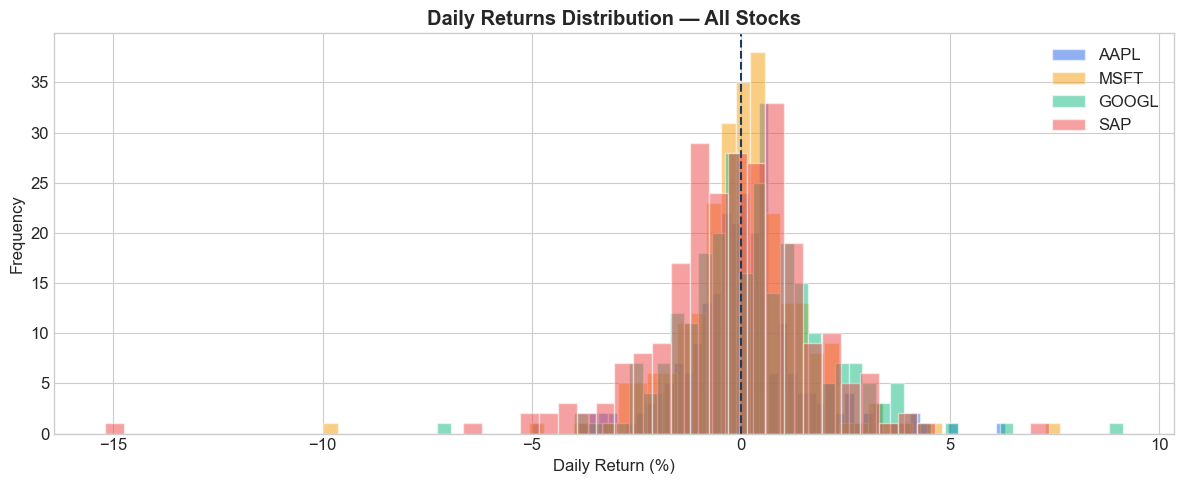

AAPL    mean=0.116%  std=1.476%  best=6.31%  worst=-5.00%
MSFT    mean=0.047%  std=1.544%  best=7.63%  worst=-9.99%
GOOGL   mean=0.319%  std=1.792%  best=9.14%  worst=-7.26%
SAP     mean=-0.160%  std=2.005%  best=7.36%  worst=-15.20%


In [ ]:
returns = data["Close"].pct_change() * 100  # percent for all tickers

fig, ax = plt.subplots()
for ticker, color in zip(tickers, colors):
    ax.hist(returns[ticker].dropna(), bins=50, alpha=0.5, label=ticker,
            edgecolor="white", color=color)

ax.axvline(0, color="#1E3A5F", linewidth=1.5, linestyle="--")
ax.set_title("Daily Returns Distribution — All Stocks", fontweight="bold")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

for ticker in tickers:
    r = returns[ticker].dropna()
    print(f"{ticker:6s}  mean={r.mean():.3f}%  std={r.std():.3f}%  best={r.max():.2f}%  worst={r.min():.2f}%")


## 9. Candlestick Chart (Simplified)

A candlestick shows Open, High, Low, Close for each day.
Green = close > open (price went up). Red = close < open (price went down).

We'll build a simple version with matplotlib bars.

## 9. Linear Regression — Price Trend with scikit-learn

We fit a simple linear regression on the AAPL closing prices over time.
The model learns: **Price ≈ a · day_number + b**

This is the simplest ML model — and a good starting point to understand
how scikit-learn works: `fit()` trains, `predict()` generates the line.


Slope:     0.3125 $/day
Intercept: 204.12 $
R² Score:  0.6898


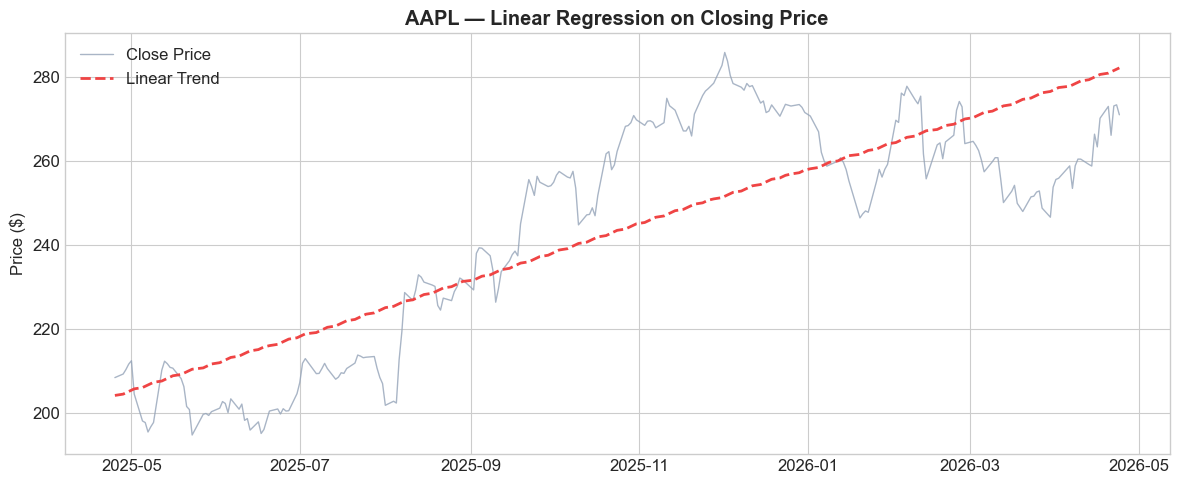

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Use AAPL closing prices from df
close = df["Close"].dropna()

# X = day number (0, 1, 2, ...), Y = closing price
X = np.arange(len(close)).reshape(-1, 1)
y = close.values.ravel()  # ensure 1D array

# Fit model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Slope:     {float(model.coef_[0]):.4f} $/day")
print(f"Intercept: {float(model.intercept_):.2f} $")
print(f"R² Score:  {float(model.score(X, y)):.4f}")

# Plot
fig, ax = plt.subplots()
ax.plot(close.index, y, color="#94A3B8", linewidth=1, alpha=0.8, label="Close Price")
ax.plot(close.index, y_pred, color="#EF4444", linewidth=2, linestyle="--", label="Linear Trend")
ax.set_title("AAPL — Linear Regression on Closing Price", fontweight="bold")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()


---
*Session 4 — Software Engineering & ML, Frankfurt UAS*